        RI     Na    Mg    Al     Si     K     Ca   Ba    Fe  \
0  1.51793  12.79  3.50  1.12  73.03  0.64   8.77  0.0  0.00   
1  1.51643  12.16  3.52  1.35  72.89  0.57   8.53  0.0  0.00   
2  1.51793  13.21  3.48  1.41  72.64  0.59   8.43  0.0  0.00   
3  1.51299  14.40  1.74  1.54  74.55  0.00   7.59  0.0  0.00   
4  1.53393  12.30  0.00  1.00  70.16  0.12  16.19  0.0  0.24   

                   Type  
0      build wind float  
1      vehic wind float  
2      build wind float  
3             tableware  
4  build wind non-float  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   RI      214 non-null    float64 
 1   Na      214 non-null    float64 
 2   Mg      214 non-null    float64 
 3   Al      214 non-null    float64 
 4   Si      214 non-null    float64 
 5   K       214 non-null    float64 
 6   Ca      214 non-null    float64 
 7   Ba     

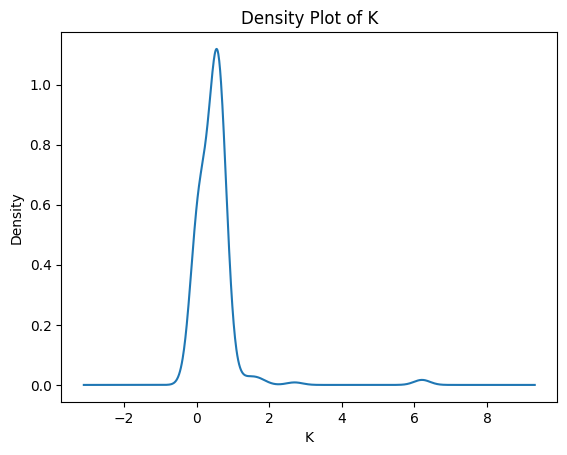

RI    1.236301
Na    0.679610
Mg   -1.154969
Al    0.863235
Si   -0.566014
K     6.085368
Ca    1.636000
Ba    3.224112
Fe    1.824102
dtype: float64
RI         NaN
Na   -0.039159
Mg   -1.371381
Al    0.063258
Si    0.097461
K    -0.262193
Ca   -0.108106
Ba    1.654662
Fe    0.683935
dtype: float64
RI    1.034938
Na   -0.043289
Mg   -0.922456
Al    0.002429
Si    0.097322
K    -0.061568
Ca   -0.125609
Ba    1.778419
Fe    0.818757
dtype: float64


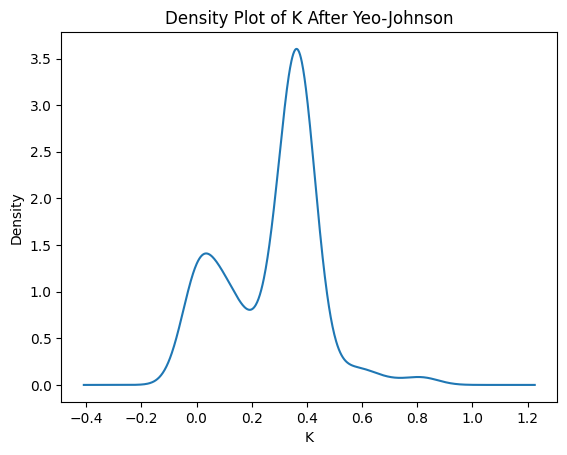

          RI        Na        Mg        Al         K        Ba        Fe
RI  1.000000 -0.191885 -0.122274 -0.407326 -0.289833 -0.000386  0.143010
Na -0.191885  1.000000 -0.273732  0.156794 -0.266087  0.326603 -0.241346
Mg -0.122274 -0.273732  1.000000 -0.481799  0.005396 -0.492262  0.083060
Al -0.407326  0.156794 -0.481799  1.000000  0.325958  0.479404 -0.074402
K  -0.289833 -0.266087  0.005396  0.325958  1.000000 -0.042618 -0.007719
Ba -0.000386  0.326603 -0.492262  0.479404 -0.042618  1.000000 -0.058692
Fe  0.143010 -0.241346  0.083060 -0.074402 -0.007719 -0.058692  1.000000


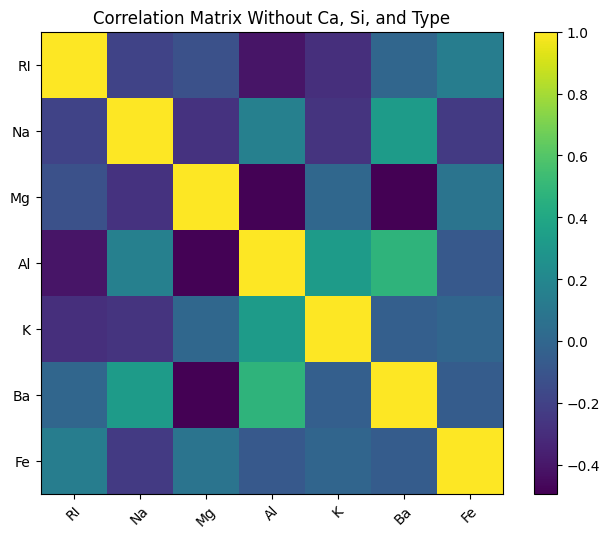

          RI        Na        Mg        Al        Si         K        Ca  \
RI  1.000000 -0.191885 -0.122274 -0.407326 -0.542052 -0.289833  0.810403   
Na -0.191885  1.000000 -0.273732  0.156794 -0.069809 -0.266087 -0.275442   
Mg -0.122274 -0.273732  1.000000 -0.481799 -0.165927  0.005396 -0.443750   
Al -0.407326  0.156794 -0.481799  1.000000 -0.005524  0.325958 -0.259592   
Si -0.542052 -0.069809 -0.165927 -0.005524  1.000000 -0.193331 -0.208732   
K  -0.289833 -0.266087  0.005396  0.325958 -0.193331  1.000000 -0.317836   
Ca  0.810403 -0.275442 -0.443750 -0.259592 -0.208732 -0.317836  1.000000   
Ba -0.000386  0.326603 -0.492262  0.479404 -0.102151 -0.042618 -0.112841   
Fe  0.143010 -0.241346  0.083060 -0.074402 -0.094201 -0.007719  0.124968   

          Ba        Fe  
RI -0.000386  0.143010  
Na  0.326603 -0.241346  
Mg -0.492262  0.083060  
Al  0.479404 -0.074402  
Si -0.102151 -0.094201  
K  -0.042618 -0.007719  
Ca -0.112841  0.124968  
Ba  1.000000 -0.058692  
Fe -0.058692  

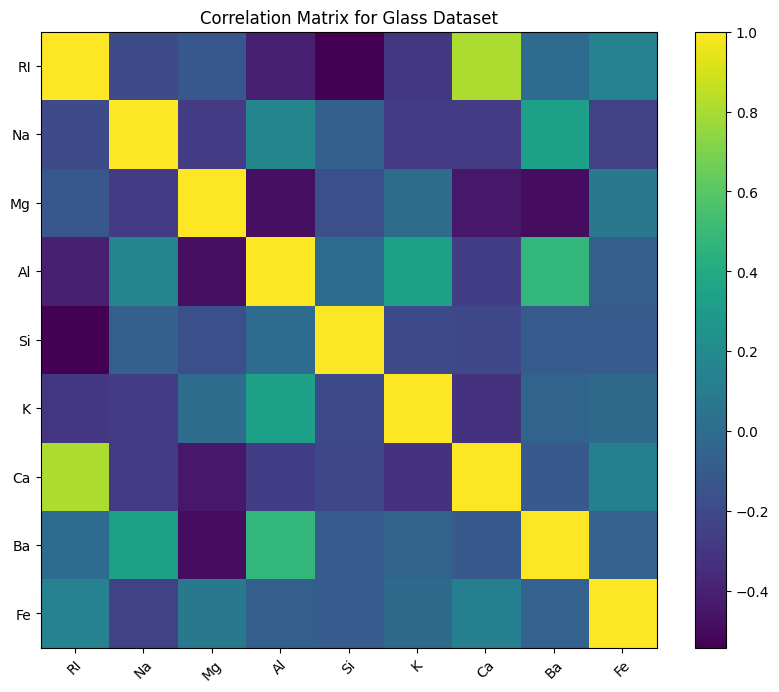

0
                            OLS Regression Results                            
Dep. Variable:                      K   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     3.521
Date:                Wed, 17 Jun 2026   Prob (F-statistic):             0.0159
Time:                        00:28:48   Log-Likelihood:                -206.43
No. Observations:                 214   AIC:                             420.9
Df Residuals:                     210   BIC:                             434.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6308      0.117      5.405      0

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from scipy.stats import skew
import statsmodels.formula.api as smf


# Load Glass dataset
glass = fetch_openml(name="glass", version=1, as_frame=True)
gdata = glass.frame.copy()

# Rename target column to Type if needed
if "Type" not in gdata.columns:
    target_col = gdata.columns[-1]
    gdata = gdata.rename(columns={target_col: "Type"})

gdata["Type"] = gdata["Type"].astype("category")

np.random.seed(123)

print(gdata.head())
print(gdata.info())


# Random train/test split
gtrain, gtest = train_test_split(
    gdata,
    test_size=0.20,
    random_state=123
)

# Stratified train/test split
gtrains, gtests = train_test_split(
    gdata,
    test_size=0.20,
    random_state=123,
    stratify=gdata["Type"]
)


# Explore key variables
Calcium = gdata["Ca"]
Silicon = gdata["Si"]
Type = gdata["Type"]


# Remove selected variables and check skewness
gdata2 = gdata.drop(columns=["Ca", "Si", "Type"])

skewness_gdata2 = gdata2.apply(lambda x: skew(x.dropna()))
print(skewness_gdata2)


# Plot potassium density
plt.figure()
gdata["K"].plot(kind="density")
plt.title("Density Plot of K")
plt.xlabel("K")
plt.show()


# Center and scale training/testing data
feature_cols = [col for col in gtrain.columns if col != "Type"]

scaler = StandardScaler()

gtrain_scaled_features = scaler.fit_transform(gtrain[feature_cols])
gtest_scaled_features = scaler.transform(gtest[feature_cols])

gtrain_scaled = pd.DataFrame(
    gtrain_scaled_features,
    columns=feature_cols,
    index=gtrain.index
)

gtest_scaled = pd.DataFrame(
    gtest_scaled_features,
    columns=feature_cols,
    index=gtest.index
)

gtrain_scaled["Type"] = gtrain["Type"]
gtest_scaled["Type"] = gtest["Type"]


# Box-Cox transformation
gtrain_positive = gtrain[feature_cols].copy()

for col in feature_cols:
    min_value = gtrain_positive[col].min()
    if min_value <= 0:
        gtrain_positive[col] = gtrain_positive[col] + abs(min_value) + 0.0001

boxcox_transformer = PowerTransformer(method="box-cox", standardize=False)
gtrainBC_features = boxcox_transformer.fit_transform(gtrain_positive)

gtrainBC = pd.DataFrame(
    gtrainBC_features,
    columns=feature_cols,
    index=gtrain.index
)

gtrainBC["Type"] = gtrain["Type"]


# Yeo-Johnson transformation
yeojohnson_transformer = PowerTransformer(method="yeo-johnson", standardize=False)
gtrainYJ_features = yeojohnson_transformer.fit_transform(gtrain[feature_cols])

gtrainYJ = pd.DataFrame(
    gtrainYJ_features,
    columns=feature_cols,
    index=gtrain.index
)

gtrainYJ["Type"] = gtrain["Type"]


# Compare skewness before and after transformations
skewness_gtrain = gtrain[feature_cols].apply(lambda x: skew(x.dropna()))
skewness_gtrainBC = gtrainBC[feature_cols].apply(lambda x: skew(x.dropna()))
skewness_gtrainYJ = gtrainYJ[feature_cols].apply(lambda x: skew(x.dropna()))

print(skewness_gtrain)
print(skewness_gtrainBC)
print(skewness_gtrainYJ)


# Plot transformed potassium density
plt.figure()
gtrainYJ["K"].plot(kind="density")
plt.title("Density Plot of K After Yeo-Johnson")
plt.xlabel("K")
plt.show()


# Correlation matrices
correlations = gdata2.corr()
print(correlations)

plt.figure(figsize=(8, 6))
plt.imshow(correlations, cmap="viridis")
plt.colorbar()
plt.xticks(range(len(correlations.columns)), correlations.columns, rotation=45)
plt.yticks(range(len(correlations.columns)), correlations.columns)
plt.title("Correlation Matrix Without Ca, Si, and Type")
plt.show()


gdata_without_type = gdata.drop(columns=["Type"])
correlations_gdata = gdata_without_type.corr()
print(correlations_gdata)

plt.figure(figsize=(10, 8))
plt.imshow(correlations_gdata, cmap="viridis")
plt.colorbar()
plt.xticks(range(len(correlations_gdata.columns)), correlations_gdata.columns, rotation=45)
plt.yticks(range(len(correlations_gdata.columns)), correlations_gdata.columns)
plt.title("Correlation Matrix for Glass Dataset")
plt.show()


# Check missing values
missing_values_check = gdata.isna().sum().sum()
print(missing_values_check)


# Linear regression model
lmresult = smf.ols("K ~ Mg * Ba", data=gdata).fit()
print(lmresult.summary())